In [1]:
# import packages
from MFVeBRNN.dataset.load_dataset import SingleFidelityDataset
from MFVeBRNN.method.rnn_trainer import RNNTrainer
import torch
import matplotlib.pyplot as plt
from torch import nn
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset = SingleFidelityDataset(train_data_path = "lf_dns_sve_0d1.pickle",
                            id_ground_truth=True,
                            id_test_data_path="hf_dns_rve_0d1_gt.pickle",
                            id_ground_truth_data_path="lf_dns_sve_0d1_gt.pickle",
                            ood_ground_truth=True,
                            ood_test_data_path="hf_dns_rve_0d125_gt.pickle",
                            ood_ground_truth_data_path='lf_dns_sve_0d125_gt.pickle',)
dataset.get_train_val_split(num_train=100,num_val=100)

The dataset is loaded successfully.
Number of training samples: 2981
Number of in-distribution test samples: 99
Number of out-of-distribution test samples: 99


In [3]:
class SimpleGRU(nn.Module):
    def __init__(self,
                 input_size: int,
                 hidden_size: int,
                 num_layers: int,
                 output_size: int,
                 bias: bool = True):
        super().__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          bias=bias,
                          batch_first=True,
                        )
        self.h2y = nn.Linear(hidden_size, output_size)

    def forward(self, x, hx=None):
        out, _ = self.gru(x, hx)      # (B, T, hidden_size)
        y = self.h2y(out)             # (B, T, output_size)
        return y

In [ ]:
# define the RNN model
rnn_network = SimpleGRU(input_size=3,
                      hidden_size=64,
                      num_layers=1,
                      output_size=3)
# define the RNN trainer
DeepRNN = RNNTrainer(
        net=rnn_network,
        device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
    )
# define the optimizer
DeepRNN.configure_optimizer_info(optimizer_name="Adam",
                                lr=0.001,
                                weight_decay=0.0)
# define the loss function
DeepRNN.configure_loss_function(loss_name="MSE")

# train the model
min_loss, min_epoch = DeepRNN.train(
    x_train=dataset.x_train,
    y_train=dataset.y_train,
    x_val=dataset.x_val,
    y_val=dataset.y_val,
    num_epochs=500,
    batch_size=100,

    print_iter=100,
    verbose=True,
)

# save the model
# torch.save(DeepRNN, "single_fidelity_rnn_model.pth")


Epoch/Total: 0/500, Train Loss: 9.183e-01, Val Loss: 9.715e-01
Epoch/Total: 100/500, Train Loss: 2.264e-01, Val Loss: 2.307e-01
Epoch/Total: 200/500, Train Loss: 3.628e-02, Val Loss: 4.075e-02
Epoch/Total: 300/500, Train Loss: 2.566e-02, Val Loss: 3.057e-02
Epoch/Total: 400/500, Train Loss: 1.943e-02, Val Loss: 2.490e-02


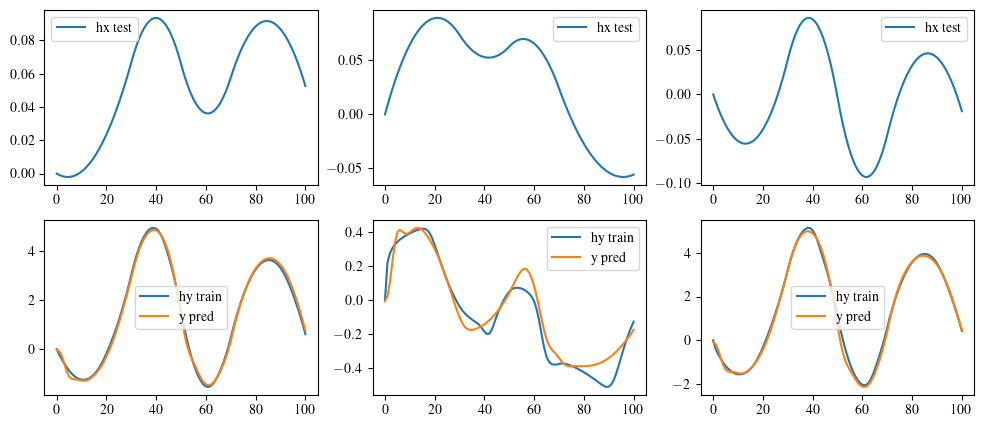

In [5]:
# get the prediction of the test data
y_pred = DeepRNN.predict(dataset.x_id_gt_scaled)
# scale back to the original space
y_pred = dataset.scale_back_outputs(y_pred.detach().cpu())
# plot the dataset
index =1
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
for i in range(3):
    ax[0, i].plot(dataset.ID_X[index, :, i], label='hx test')
    ax[0, i].legend()
    ax[1, i].plot(dataset.ID_Y[index, :, i], label='hy train')
    ax[1, i].plot(y_pred.cpu()[index, :, i], label='y pred')
    ax[1, i].legend()

plt.show()
